In [1]:
!pip install torch

In [2]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0


In [3]:
#define training data
@dataclass(frozen=True)
class Example:
    x: float
    target_y: float

#define parameters
@dataclass
class Parameters:
    weight: float
    bias: float

def get_training_data() -> list[Example]:
    return [
        Example(x=1.0, target_y=4.0),
        Example(x=2.0, target_y=6.0),
        Example(x=4.0, target_y=7.0),
    ]

training_data = get_training_data()
print("Training data:", training_data)

Training data: [Example(x=1.0, target_y=4.0), Example(x=2.0, target_y=6.0), Example(x=4.0, target_y=7.0)]


In [ ]:
#define model (linear function)
def f(params: Parameters, x: float) -> float:
    return params.weight * x + params.bias


initial_params = Parameters(
    weight=2.0, bias=1.0
)
print("when x is 3, predicted output is 7:", f(
    initial_params, 3.0
))

when x is 3, predicted output is 7: 7.0


In [ ]:
# loss function
def compute_loss(params: Parameters, example: Example) -> float:
    residual = f(params=params, x=example.x) - example.target_y
    return residual ** 2

# mean loss of all training data
def compute_training_loss(params: Parameters, training_data: list[Example]) -> float:
    losses = [compute_loss(params=params, example=example) for example in training_data]
    return float(np.mean(losses))

initial_params = Parameters(weight=1.0, bias=0.0)
print("initial training loss:", compute_training_loss(params=initial_params, training_data=get_training_data()))


initial training loss: 11.333333333333334


In [ ]:
# compute gradient of the loss
def compute_gradient_loss(params: Parameters, example: Example) -> np.ndarray:
    residual = f(params=params, x=example.x) - example.target_y
    # d(loss) / d(weight) = 2 * residual * x
    # d(loss) / d(bias) = 2 * residual
    return 2 * residual * np.array([example.x, 1.0])

# compute mean gradient of the training data loss
def compute_gradient_train_loss(params: Parameters, training_data: list[Example]) -> np.ndarray:
    gradients = [compute_gradient_loss(params=params, example=example) for example in training_data]
    return np.mean(gradients, axis=0)

print("initial gradient [dLoss/dw, dLoss/db]:", compute_gradient_train_loss(params=initial_params, training_data=get_training_data()))

initial gradient [dLoss/dw, dLoss/db]: [-15.33333333  -6.66666667]


In [16]:
# gradient descend
def gradient_descend(training_data: list[Example], num_steps: int = 100, learning_rate: float = 0.01):
    params = Parameters(weight=0.0, bias=1.0)
    loss_history = []

    for step in range(num_steps):
        loss = compute_training_loss(params=params, training_data=training_data)
        loss_history.append(loss)

        #compute gradient
        gradient = compute_gradient_train_loss(params=params, training_data=training_data)

        #optimize params
        params = Parameters(
            weight=params.weight - gradient[0] * learning_rate, 
            bias=params.bias - gradient[1] * learning_rate)

        #print loss and params in every 10 steps
        if (step + 1) % 10 == 0 or step == 0:
            print(f"Step {step+1:3d} | Loss: {loss:.4f} | Weight: {params.weight:.4f} | Bias: {params.bias:.4f}")

    return params, loss_history

trained_params, loss_history = gradient_descend(training_data=get_training_data(), num_steps=100)

Step   1 | Loss: 23.3333 | Weight: 0.2467 | Bias: 1.0933
Step  10 | Loss: 2.0558 | Weight: 1.2789 | Bias: 1.5242
Step  20 | Loss: 0.9790 | Weight: 1.4930 | Bias: 1.6798
Step  30 | Loss: 0.8888 | Weight: 1.5127 | Bias: 1.7655
Step  40 | Loss: 0.8359 | Weight: 1.4975 | Bias: 1.8360
Step  50 | Loss: 0.7882 | Weight: 1.4766 | Bias: 1.9017
Step  60 | Loss: 0.7441 | Weight: 1.4554 | Bias: 1.9644
Step  70 | Loss: 0.7034 | Weight: 1.4348 | Bias: 2.0246
Step  80 | Loss: 0.6658 | Weight: 1.4150 | Bias: 2.0824
Step  90 | Loss: 0.6311 | Weight: 1.3959 | Bias: 2.1379
Step 100 | Loss: 0.5991 | Weight: 1.3776 | Bias: 2.1913


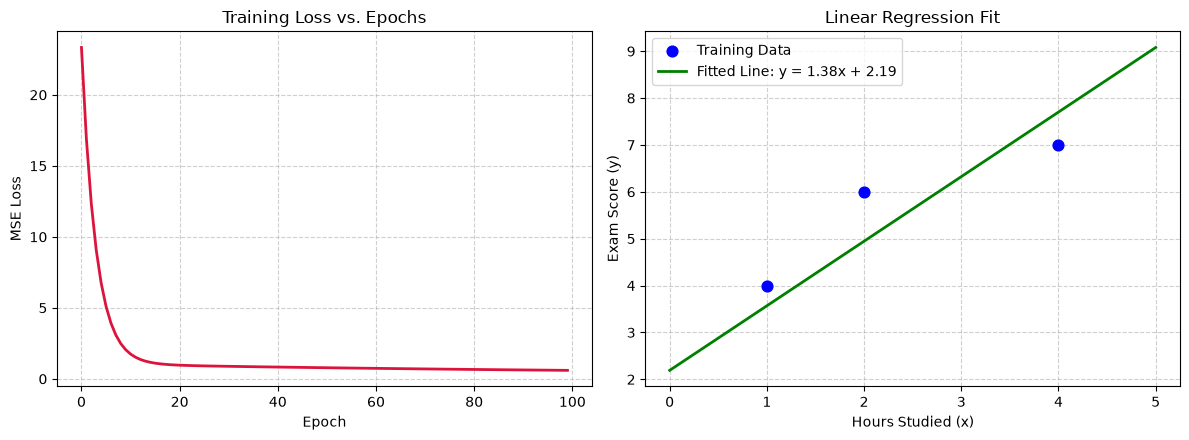

In [17]:
# display gradient decend
x_pts = [ex.x for ex in training_data]
y_pts = [ex.target_y for ex in training_data]

# create canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. draw Loss 
ax1.plot(loss_history, color='crimson', lw=2)
ax1.set_title("Training Loss vs. Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.grid(True, linestyle='--', alpha=0.6)

x_line = np.linspace(0, 5, 100)
y_line = [f(trained_params, x) for x in x_line]

ax2.scatter(x_pts, y_pts, color='blue', s=60, label="Training Data", zorder=3)
ax2.plot(x_line, y_line, color='green', lw=2, label=f"Fitted Line: y = {trained_params.weight:.2f}x + {trained_params.bias:.2f}")
ax2.set_title("Linear Regression Fit")
ax2.set_xlabel("Hours Studied (x)")
ax2.set_ylabel("Exam Score (y)")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()